In [1]:
import numpy as np
import pandas as pd
import glob
import os
import sys
import soundfile

In [2]:
import librosa
import librosa.display
import seaborn as sbn
import matplotlib.pyplot as plt
from sklearn import metrics

In [3]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier

In [4]:
from IPython.display import Audio

## Dataset :
- Here we have used Revdess Dataset which contains audio files of 24 different voice actors along with different emotions.
- Name of audio file contains 7 parts(i.e. 03-01-06-01-02-01-12.wav), denoting 7 different things.
    - Modality (01 = full-AV, 02 = video-only, 03 = audio-only)
    - Vocal channel (01 = speech, 02 = song)
    - Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised)
    - Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion
    - Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door")
    - Repetition (01 = 1st repetition, 02 = 2nd repetition)
    - Actor (01 to 24. Odd numbered actors are male, even numbered actors are female)


For Example : 03-01-06-01-02-01-12.wav
1. Audio-only (03)
2. Speech (01)
3. Fearful (06)
4. Normal intensity (01)
5. Statement "dogs" (02)
6. 1st Repetition (01)
7. 12th Actor (12)
   Female, as the actor ID number is even.


## Preprocessing :

In [5]:
root_dir = "audio_speech_actors_01-24\\"
dir_list = os.listdir(root_dir)
# dir_list

file_emotion = []
file_path = []

for dir in dir_list:
    path = os.listdir(root_dir + dir)
    for file in path:
        parts = file.split('.')[0]
        parts = parts.split('-')

        file_emotion.append(int(parts[2]))
        file_path.append(root_dir + dir + '\\' + file)

emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])
path_df = pd.DataFrame(file_path, columns=['Path'])

df = pd.concat([path_df, emotion_df], axis=1)
df.head()

,Path,Emotions
0,audio_speech_actors_01-24\Actor_01\03-01-01-01...,1
1,audio_speech_actors_01-24\Actor_01\03-01-01-01...,1
2,audio_speech_actors_01-24\Actor_01\03-01-01-01...,1
3,audio_speech_actors_01-24\Actor_01\03-01-01-01...,1
4,audio_speech_actors_01-24\Actor_01\03-01-02-01...,2


In [6]:
df["Emotions"] = df["Emotions"].replace({1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprised'})
df.head()

,Path,Emotions
0,audio_speech_actors_01-24\Actor_01\03-01-01-01...,neutral
1,audio_speech_actors_01-24\Actor_01\03-01-01-01...,neutral
2,audio_speech_actors_01-24\Actor_01\03-01-01-01...,neutral
3,audio_speech_actors_01-24\Actor_01\03-01-01-01...,neutral
4,audio_speech_actors_01-24\Actor_01\03-01-02-01...,calm


In [7]:
data_path = pd.concat([df], axis=0)
data_path.to_csv("speech_file_path.csv", index=False)
data_path.head()

,Path,Emotions
0,audio_speech_actors_01-24\Actor_01\03-01-01-01...,neutral
1,audio_speech_actors_01-24\Actor_01\03-01-01-01...,neutral
2,audio_speech_actors_01-24\Actor_01\03-01-01-01...,neutral
3,audio_speech_actors_01-24\Actor_01\03-01-01-01...,neutral
4,audio_speech_actors_01-24\Actor_01\03-01-02-01...,calm


In [8]:
data_path["Emotions"].describe()

count     1440
unique       8
top       calm
freq       192
Name: Emotions, dtype: object

<Axes: xlabel='count', ylabel='Emotions'>

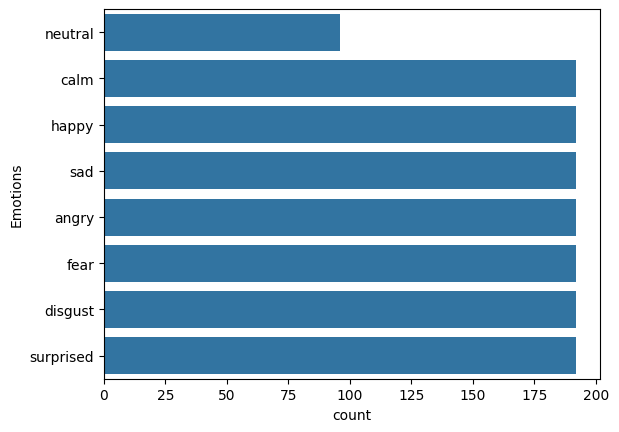

In [9]:
sbn.countplot(data_path["Emotions"])

**Waveplot Function:** create_waveplot displays the waveform of an audio sample to observe how the amplitude changes over time.

In [10]:
def create_waveplot(data, sr, emotion):
    plt.figure(figsize=(10, 3))
    plt.title(f"Waveplot of audio with emotion {emotion}")
    librosa.display.waveshow(data, sr=sr)
    plt.show()

- The default sampling rate in librosa is 22,050. This value is well suited for music signals.
- The sampling rate --- typically fs in the digital signal processing literature, or sr in librosa --- is defined as 1/ts, where ts is the amount of time (in seconds) between successive samples. Equivalently, fs is the number of observations per second in the discretely sampled signal.

**Spectrogram Function:** create_spectogram generates a spectrogram for an audio sample. A spectrogram visualizes the frequency content of the audio over time, helping to analyze audio characteristics in the frequency domain.

In [11]:
def create_spectogram(data, sr, emotion):
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(abs(X))
    plt.figure(figsize=(12, 3))
    plt.title(f"Spectrogram of audio with emotion {emotion}")
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()

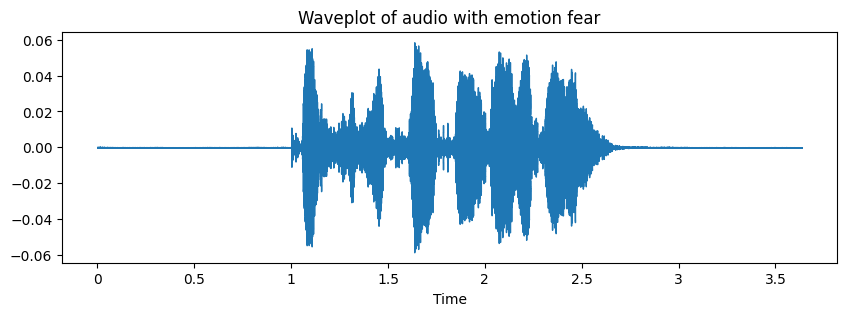

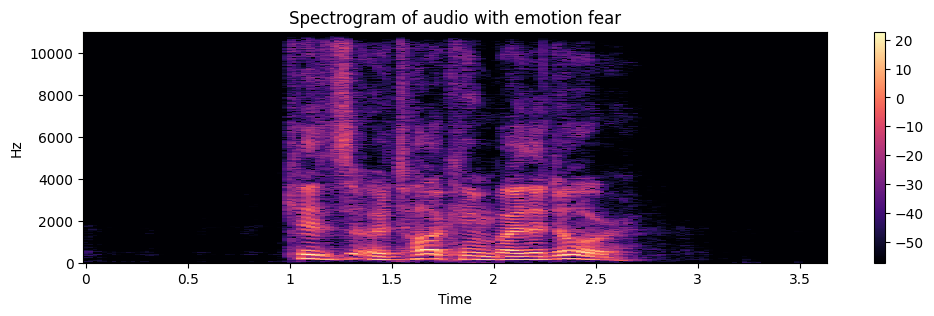

In [12]:
emotion = 'fear'
path = np.array(data_path.Path[data_path.Emotions == emotion])[1]
data, sr = librosa.load(path)
create_waveplot(data, sr, emotion)
create_spectogram(data, sr, emotion)
Audio(path)

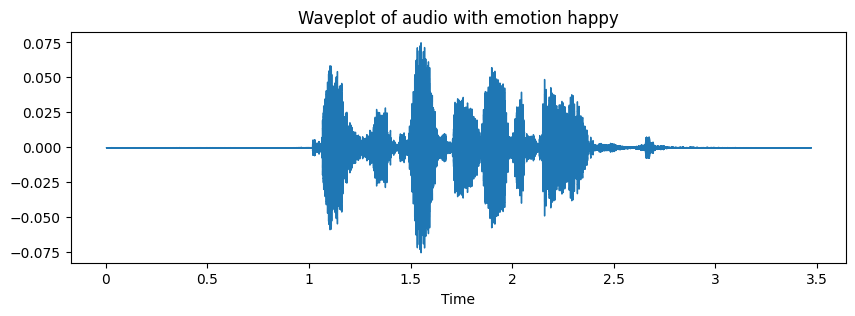

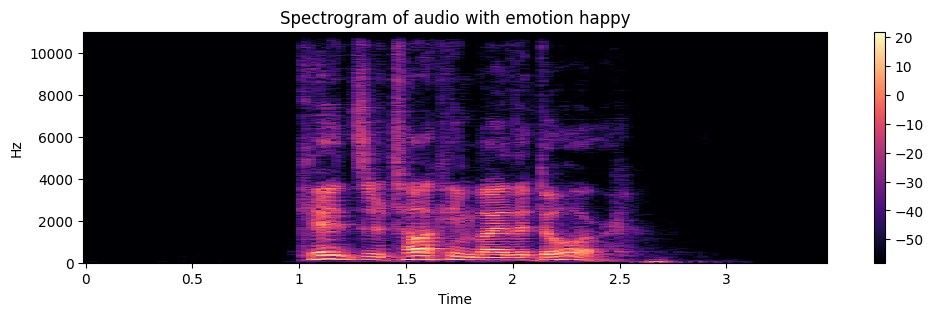

In [13]:
emotion = 'happy'
path = np.array(data_path.Path[data_path.Emotions == emotion])[1]
data, sr = librosa.load(path)
create_waveplot(data, sr, emotion)
create_spectogram(data, sr, emotion)
Audio(path)

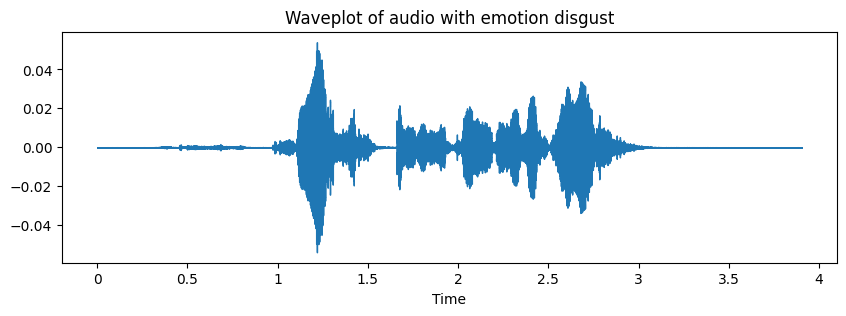

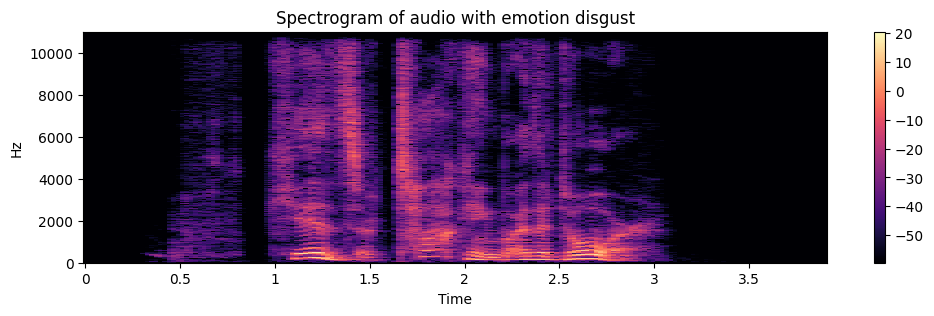

In [14]:
emotion = 'disgust'
path = np.array(data_path.Path[data_path.Emotions == emotion])[1]
data, sr = librosa.load(path)
create_waveplot(data, sr, emotion)
create_spectogram(data, sr, emotion)
Audio(path)

In [15]:
def noise(data):
    noiseAmp = 0.035 * np.random.uniform() * np.amax(data)
    data = data + noiseAmp * np.random.normal(size=data.shape[0])
    return data

def stretch(datas):
    return librosa.effects.time_stretch(y=data, rate=0.8)

def shift(data):
    shiftRange = int(np.random.uniform(low=5, high=5) * 1000)
    return np.roll(data, shiftRange)

def pitch(data, samplingRate):
    return librosa.effects.pitch_shift(data, sr=samplingRate, n_steps=0.7)

In [16]:
len(data)

86081

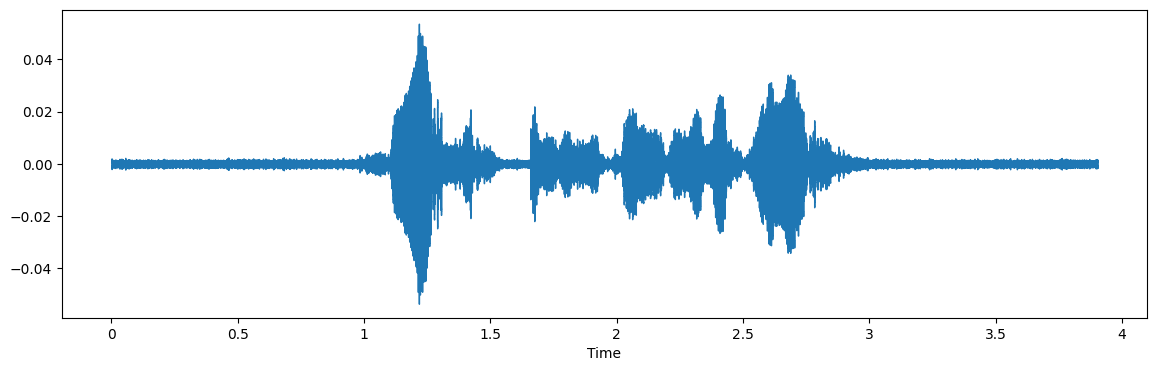

In [17]:
x = noise(data)
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y=x, sr=sr)
Audio(x, rate=sr)

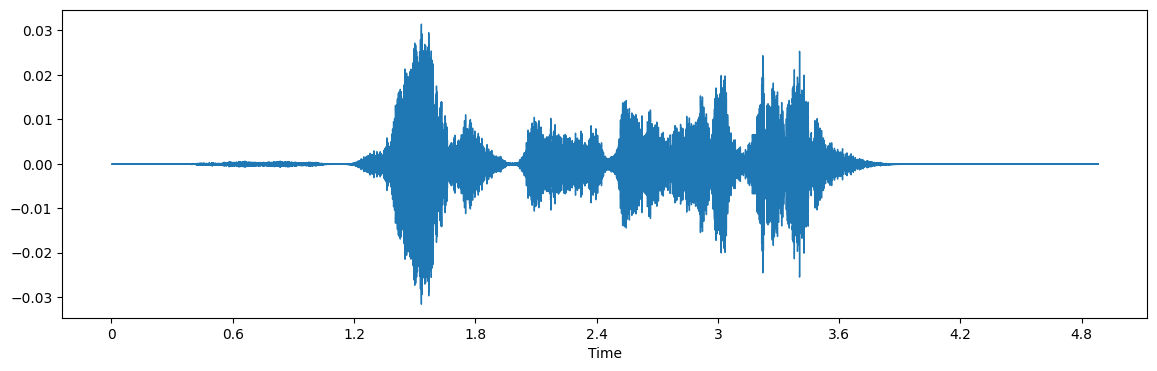

In [18]:
x = stretch(data)
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y=x, sr=sr)
Audio(x, rate=sr)

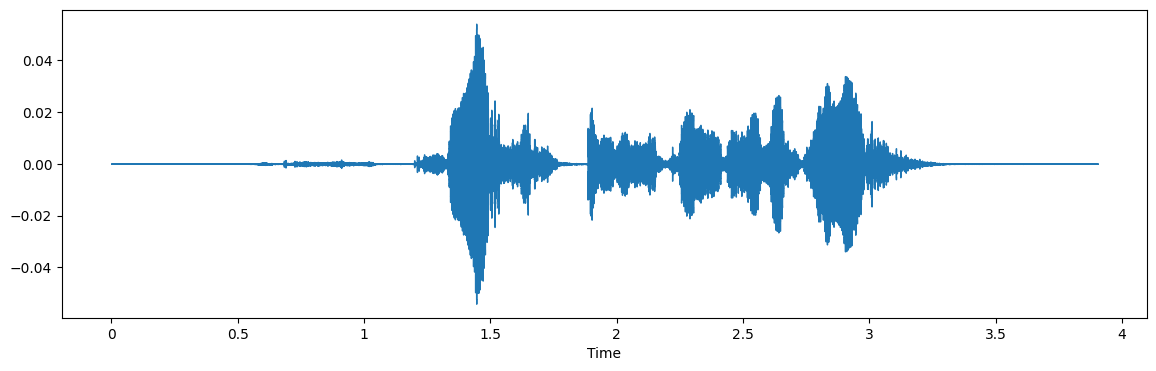

In [19]:
x = shift(data)
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y=x, sr=sr)
Audio(x, rate=sr)

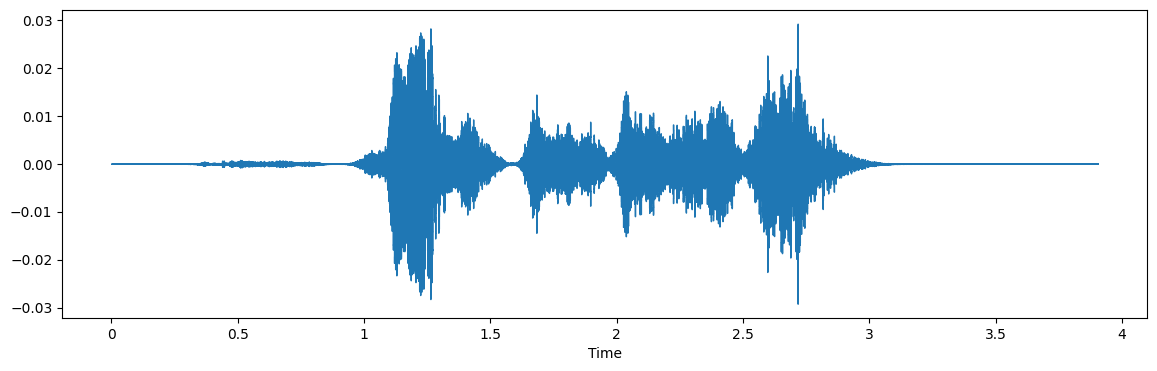

In [20]:
x = pitch(data, sr)
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y=x, sr=sr)
Audio(x, rate=sr)

## Feature Extraction :

In [21]:
def extract_features(file_path):
    data, sr = librosa.load(file_path)
    mfccs = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40)
    chroma = librosa.feature.chroma_stft(y=data, sr=sr)
    mel = librosa.feature.melspectrogram(y=data, sr=sr)
    # contrast = librosa.feature.spectral_contrast(y=data, sr=sr)
    # tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(data), sr=sr)
    return np.hstack([
        np.mean(mfccs, axis=1), np.mean(chroma, axis=1), np.mean(mel, axis=1),
        # np.mean(contrast, axis=1), np.mean(tonnetz, axis=1)
    ])

In [22]:
X, y = [], []
for index, row in data_path.iterrows():
    # print(row['Path'])
    feature = extract_features(row['Path'])
    X.append(feature)
    y.append(row['Emotions'])

In [23]:
X = np.array(X)
y = np.array(y)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1152, 180), (288, 180), (1152,), (288,))

## Model Training :

In [25]:
# model = MLPClassifier(hidden_layer_sizes=(300,), learning_rate_init=0.01, verbose=True)
model = MLPClassifier(hidden_layer_sizes=(300, 150), activation='tanh', learning_rate_init=0.001, random_state=42)
model.fit(X_train, y_train)

MLPClassifier(activation='tanh', hidden_layer_sizes=(300, 150), random_state=42)

In [26]:
y_pred = model.predict(X_test)


Accuracy: 0.6215277777777778
Classification Report:
               precision    recall  f1-score   support

       angry       0.82      0.71      0.76        38
        calm       0.67      0.62      0.64        39
     disgust       0.56      0.58      0.57        38
        fear       0.56      0.74      0.64        39
       happy       0.70      0.55      0.62        38
     neutral       0.47      0.42      0.44        19
         sad       0.47      0.49      0.48        39
   surprised       0.71      0.76      0.73        38

    accuracy                           0.62       288
   macro avg       0.62      0.61      0.61       288
weighted avg       0.63      0.62      0.62       288



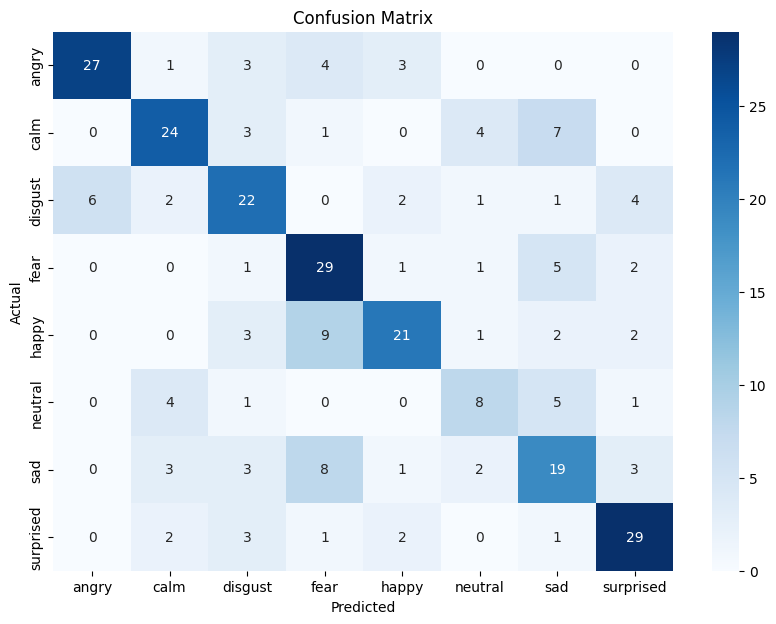

In [27]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report for precision, recall, f1-score per class
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sbn.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Fitting 3 folds for each of 18 candidates, totalling 54 fits


C:\Users\maych\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Best Parameters: {'activation': 'tanh', 'hidden_layer_sizes': (300,), 'learning_rate_init': 0.001}
Accuracy: 0.6076
Classification Report:
               precision    recall  f1-score   support

       angry       0.70      0.74      0.72        38
        calm       0.64      0.77      0.70        39
     disgust       0.45      0.50      0.47        38
        fear       0.67      0.56      0.61        39
       happy       0.59      0.58      0.59        38
     neutral       0.50      0.26      0.34        19
         sad       0.57      0.67      0.61        39
   surprised       0.70      0.61      0.65        38

    accuracy                           0.61       288
   macro avg       0.60      0.59      0.59       288
weighted avg       0.61      0.61      0.60       288



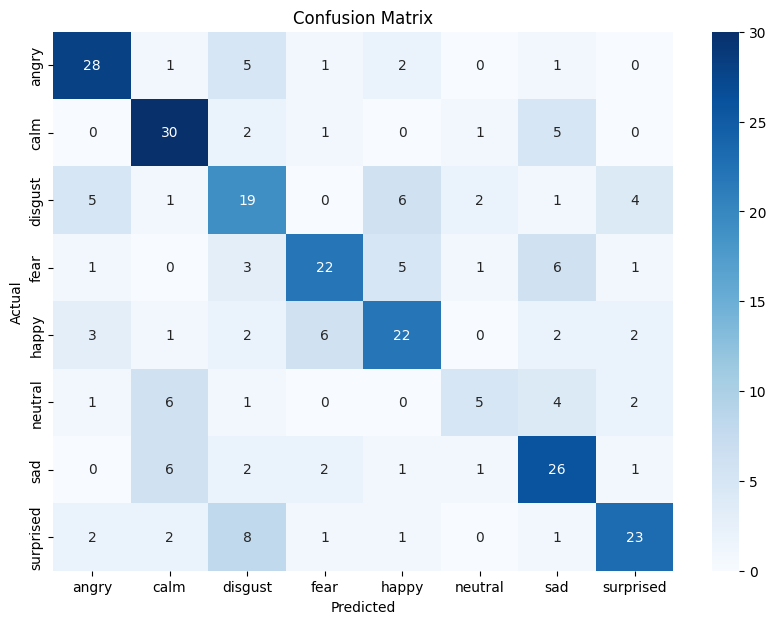

In [28]:
param_grid = {
    'hidden_layer_sizes': [(300,), (300, 150), (300, 150, 100)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01, 0.1],
    # 'alpha': [0.0001, 0.001, 0.01],
    # 'max_iter': [200, 300, 500]
}

mlp = MLPClassifier(random_state=42)
grid_search = GridSearchCV(mlp, param_grid, cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

grid_search.fit(X_train, y_train)

# Best parameters and model evaluation
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# Make predictions and evaluate
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sbn.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()